🎯 Example 1: Sequential Multi-Agent System (Pipeline)
🧠 Scenario

“A travel company has different employees (agents):

Planner → decides steps

Flight Agent → finds flights

Weather Agent → checks weather

Decision Agent → gives final answer”

In [1]:
# ================================
# AGENT 1: PLANNER
# ================================
def planner_agent(user_query):
    print("\n[Planner Agent] Creating plan...")
    return ["flight", "weather", "decision"]


# ================================
# AGENT 2: FLIGHT AGENT
# ================================
def flight_agent():
    print("\n[Flight Agent] Fetching flights...")
    return [
        {"airline": "IndiGo", "price": 4500},
        {"airline": "Air India", "price": 5200}
    ]


# ================================
# AGENT 3: WEATHER AGENT
# ================================
def weather_agent():
    print("\n[Weather Agent] Checking weather...")
    return {"condition": "Clear", "temp": 28}


# ================================
# AGENT 4: DECISION AGENT
# ================================
def decision_agent(flights, weather):
    print("\n[Decision Agent] Making decision...")

    cheapest = min(flights, key=lambda x: x["price"])

    if weather["condition"] == "Rain":
        return "Avoid travel due to bad weather"

    return f"Book {cheapest['airline']} at ₹{cheapest['price']}"


# ================================
# MAIN MULTI-AGENT SYSTEM
# ================================
def travel_multi_agent(user_query):
    print("User Query:", user_query)

    plan = planner_agent(user_query)

    flights = None
    weather = None

    for step in plan:
        if step == "flight":
            flights = flight_agent()

        elif step == "weather":
            weather = weather_agent()

        elif step == "decision":
            result = decision_agent(flights, weather)

    return result


# RUN
response = travel_multi_agent("Plan my trip Delhi to Mumbai")
print("\nFinal Answer:", response)

User Query: Plan my trip Delhi to Mumbai

[Planner Agent] Creating plan...

[Flight Agent] Fetching flights...

[Weather Agent] Checking weather...

[Decision Agent] Making decision...

Final Answer: Book IndiGo at ₹4500


Scenario
“A hospital uses different employees (agents) to handle patient care in sequence.”

================================
AGENT 1: Intake Agent (Planner)
- Collects patient symptoms and history
- Decides which steps are needed (tests, consultations, etc.)

================================
AGENT 2: Diagnostic Agent
- Orders lab tests or scans
- Interprets results and identifies possible conditions

================================
AGENT 3: Treatment Agent
- Suggests treatment options (medication, therapy, surgery)
- Considers patient preferences and medical guidelines

================================
AGENT 4: Decision Agent
- Reviews all inputs (history, diagnostics, treatment options)
- Provides the final recommendation to the patient

In [2]:
# ================================
# AGENT 1: INTAKE AGENT (PLANNER)
# ================================
def intake_agent(patient_query):
    print("\n[Intake Agent] Collecting patient info...")

    patient_data = {
        "symptoms": ["fever", "cough"],
        "history": "no major illness"
    }

    plan = ["diagnosis", "treatment", "decision"]
    return patient_data, plan


# ================================
# AGENT 2: DIAGNOSTIC AGENT
# ================================
def diagnostic_agent(patient_data):
    print("\n[Diagnostic Agent] Running tests...")

    # Simulated diagnosis logic
    if "fever" in patient_data["symptoms"]:
        diagnosis = "Possible Viral Infection"
    else:
        diagnosis = "General Checkup Needed"

    return {
        "diagnosis": diagnosis,
        "tests": ["Blood Test", "X-Ray"]
    }


# ================================
# AGENT 3: TREATMENT AGENT
# ================================
def treatment_agent(diagnostic_report):
    print("\n[Treatment Agent] Suggesting treatment...")

    if "Viral" in diagnostic_report["diagnosis"]:
        treatment = ["Paracetamol", "Rest", "Hydration"]
    else:
        treatment = ["Further Evaluation"]

    return {
        "treatment_plan": treatment
    }


# ================================
# AGENT 4: DECISION AGENT
# ================================
def decision_agent(patient_data, diagnostic_report, treatment_plan):
    print("\n[Decision Agent] Final recommendation...")

    return f"""
Diagnosis: {diagnostic_report['diagnosis']}
Recommended Tests: {', '.join(diagnostic_report['tests'])}
Treatment: {', '.join(treatment_plan['treatment_plan'])}
Advice: Follow up in 3 days if symptoms persist
"""


# ================================
# MAIN MULTI-AGENT SYSTEM
# ================================
def hospital_multi_agent(patient_query):
    print("Patient Query:", patient_query)

    patient_data, plan = intake_agent(patient_query)

    diagnostic_report = None
    treatment_plan = None

    for step in plan:
        if step == "diagnosis":
            diagnostic_report = diagnostic_agent(patient_data)

        elif step == "treatment":
            treatment_plan = treatment_agent(diagnostic_report)

        elif step == "decision":
            result = decision_agent(
                patient_data,
                diagnostic_report,
                treatment_plan
            )

    return result


# RUN
response = hospital_multi_agent("I have fever and cough")
print("\nFinal Recommendation:", response)

Patient Query: I have fever and cough

[Intake Agent] Collecting patient info...

[Diagnostic Agent] Running tests...

[Treatment Agent] Suggesting treatment...

[Decision Agent] Final recommendation...

Final Recommendation: 
Diagnosis: Possible Viral Infection
Recommended Tests: Blood Test, X-Ray
Treatment: Paracetamol, Rest, Hydration
Advice: Follow up in 3 days if symptoms persist



In [2]:
import requests
import os
from dotenv import load_dotenv

load_dotenv()

API_TOKEN = os.getenv("API_KEY_HUGG")
API_URL = "https://router.huggingface.co/v1/chat/completions"

headers = {
    "Authorization": f"Bearer {API_TOKEN}",
    "Content-Type": "application/json"
}

MODEL_ID = "meta-llama/Meta-Llama-3-8B-Instruct"


# ================================
# AGENT 1: INTAKE AGENT
# ================================
def intake_agent(patient_query):
    print("\n[Intake Agent] Collecting patient info...")

    patient_data = {
        "query": patient_query,
        "history": "no major illness"
    }

    plan = ["diagnosis", "treatment", "decision"]
    return patient_data, plan


# ================================
# HELPER: CALL HUGGING FACE LLM
# ================================
def call_llm(prompt):
    payload = {
        "model": MODEL_ID,
        "messages": [
            {"role": "user", "content": prompt}
        ],
        "max_tokens": 200
    }

    response = requests.post(API_URL, headers=headers, json=payload)
    return response.json()["choices"][0]["message"]["content"]


# ================================
# AGENT 2: DIAGNOSTIC AGENT (LLM)
# ================================
def diagnostic_agent(patient_data):
    print("\n[Diagnostic Agent] Running AI diagnosis...")

    prompt = f"""
    Patient symptoms: {patient_data['query']}
    Medical history: {patient_data['history']}

    Give:
    1. Possible diagnosis
    2. Suggested tests
    Keep it short.
    """

    result = call_llm(prompt)

    return {"llm_diagnosis": result}


# ================================
# AGENT 3: TREATMENT AGENT (LLM)
# ================================
def treatment_agent(diagnostic_report):
    print("\n[Treatment Agent] Generating treatment plan...")

    prompt = f"""
    Based on this diagnosis:
    {diagnostic_report['llm_diagnosis']}

    Suggest treatment options.
    Keep it short.
    """

    result = call_llm(prompt)

    return {"treatment_plan": result}


# ================================
# AGENT 4: DECISION AGENT
# ================================
def decision_agent(patient_data, diagnostic_report, treatment_plan):
    print("\n[Decision Agent] Final recommendation...")

    return f"""
=== FINAL MEDICAL REPORT ===

Patient Query:
{patient_data['query']}

Diagnosis:
{diagnostic_report['llm_diagnosis']}

Treatment Plan:
{treatment_plan['treatment_plan']}

Advice:
Consult a doctor before taking medication.
"""


# ================================
# MAIN SYSTEM
# ================================
def hospital_multi_agent(patient_query):
    print("Patient Query:", patient_query)

    patient_data, plan = intake_agent(patient_query)

    diagnostic_report = None
    treatment_plan = None

    for step in plan:
        if step == "diagnosis":
            diagnostic_report = diagnostic_agent(patient_data)

        elif step == "treatment":
            treatment_plan = treatment_agent(diagnostic_report)

        elif step == "decision":
            result = decision_agent(
                patient_data,
                diagnostic_report,
                treatment_plan
            )

    return result


# RUN
response = hospital_multi_agent("I have fever, cough and headache")
print(response)

Patient Query: I have fever, cough and headache

[Intake Agent] Collecting patient info...

[Diagnostic Agent] Running AI diagnosis...

[Treatment Agent] Generating treatment plan...

[Decision Agent] Final recommendation...

=== FINAL MEDICAL REPORT ===

Patient Query:
I have fever, cough and headache

Diagnosis:
**Possible Diagnosis:**
Given the symptoms of fever, cough, and headache, possible diagnoses include:

1. Common Cold
2. Viral Pneumonia
3. Influenza (Flu)

**Suggested Tests:**
To confirm the diagnosis, the following tests may be suggested:

1. Rapid Influenza Test (RIT) to check for Influenza
2. Complete Blood Count (CBC) to rule out bacterial infections
3. Chest X-ray to check for pneumonia or other lung infections

However, a definitive diagnosis may require a physical examination and a detailed medical history.

Treatment Plan:
**Treatment Options:**

Based on the possible diagnoses, the following treatment options may be suggested:

1. **Common Cold:**
   - Rest and hyd

Scenario: Corporate Market Research & Strategy
A company wants to explore launching a new product in a competitive market. The Manager Agent oversees the process and delegates tasks to specialized workers.

👩‍💼 Manager Agent
- Receives the overall goal: “Evaluate feasibility of launching Product Y in Asia.”
- Dynamically assigns tasks to worker agents depending on what’s needed.
- Example: If budget is unclear → send to Finance Worker. If regulations are complex → send to Legal Worker.

================================
📊 Worker Agents
================================
- Market Research Worker
- Collects competitor data, customer preferences, and demand forecasts.
- Reports: “High demand in Tier‑1 cities, moderate competition.”
- Finance Worker
- Analyzes budget, ROI, and pricing strategy.
- Reports: “Estimated $10M investment, ROI in 2 years.”
- Operations Worker
- Evaluates supply chain, production capacity, and logistics.
- Reports: “Factories can scale up, but shipping costs are high.”
- Legal Worker
- Reviews compliance, intellectual property, and regional regulations.
- Reports: “Trademark available, but import laws require certification.”
- HR Worker
- Assesses staffing needs and training requirements.
- Reports: “Need 50 new hires for customer support and sales.”

In [3]:
# ================================
# AGENT 1: MANAGER AGENT (PLANNER)
# ================================
def manager_agent(goal):
    print("\n[Manager Agent] Planning tasks...")

    # Simple rule-based planning
    plan = ["market", "finance", "operations", "legal", "hr"]
    return plan


# ================================
# AGENT 2: MARKET RESEARCH WORKER
# ================================
def market_worker():
    print("\n[Market Research Worker] Analyzing market...")

    return {
        "demand": "High in Tier-1 cities",
        "competition": "Moderate"
    }


# ================================
# AGENT 3: FINANCE WORKER
# ================================
def finance_worker():
    print("\n[Finance Worker] Analyzing financials...")

    return {
        "investment": "$10M",
        "roi": "2 years"
    }


# ================================
# AGENT 4: OPERATIONS WORKER
# ================================
def operations_worker():
    print("\n[Operations Worker] Checking operations...")

    return {
        "capacity": "Can scale production",
        "logistics": "High shipping cost"
    }


# ================================
# AGENT 5: LEGAL WORKER
# ================================
def legal_worker():
    print("\n[Legal Worker] Reviewing legal compliance...")

    return {
        "trademark": "Available",
        "risk": "Import certification required"
    }


# ================================
# AGENT 6: HR WORKER
# ================================
def hr_worker():
    print("\n[HR Worker] Evaluating staffing...")

    return {
        "hiring": "50 employees needed",
        "roles": ["Sales", "Customer Support"]
    }


# ================================
# AGENT 7: DECISION AGENT
# ================================
def decision_agent(market, finance, operations, legal, hr):
    print("\n[Decision Agent] Making final decision...")

    # Simple decision logic
    if "High" in market["demand"] and "2 years" in finance["roi"]:
        return "Launch Product Y in Asia with cost optimization strategies"
    else:
        return "Further analysis required before launch"


# ================================
# MAIN MULTI-AGENT SYSTEM
# ================================
def corporate_multi_agent(goal):
    print("Goal:", goal)

    plan = manager_agent(goal)

    market = finance = operations = legal = hr = None

    for step in plan:
        if step == "market":
            market = market_worker()

        elif step == "finance":
            finance = finance_worker()

        elif step == "operations":
            operations = operations_worker()

        elif step == "legal":
            legal = legal_worker()

        elif step == "hr":
            hr = hr_worker()

    result = decision_agent(market, finance, operations, legal, hr)

    return result


# RUN
response = corporate_multi_agent(
    "Evaluate feasibility of launching Product Y in Asia"
)

print("\nFinal Decision:", response)

Goal: Evaluate feasibility of launching Product Y in Asia

[Manager Agent] Planning tasks...

[Market Research Worker] Analyzing market...

[Finance Worker] Analyzing financials...

[Operations Worker] Checking operations...

[Legal Worker] Reviewing legal compliance...

[HR Worker] Evaluating staffing...

[Decision Agent] Making final decision...

Final Decision: Launch Product Y in Asia with cost optimization strategies


In [ ]:
import requests
import os
from dotenv import load_dotenv

load_dotenv()

API_TOKEN = os.getenv("API_KEY_HUGG")
API_URL = "https://router.huggingface.co/v1/chat/completions"

headers = {
    "Authorization": f"Bearer {API_TOKEN}",
    "Content-Type": "application/json"
}

MODEL_ID = "meta-llama/Meta-Llama-3-8B-Instruct"


# ================================
# HELPER: LLM CALL
# ================================
def call_llm(prompt):
    payload = {
        "model": MODEL_ID,
        "messages": [{"role": "user", "content": prompt}],
        "max_tokens": 200
    }

    response = requests.post(API_URL, headers=headers, json=payload)
    return response.json()["choices"][0]["message"]["content"]


# ================================
# WORKER AGENTS
# ================================
def market_research_worker(goal):
    print("\n[Market Research Worker] Analyzing market...")

    prompt = f"""
    Evaluate market demand, competition, and customer trends for:
    {goal}
    Keep answer short.
    """
    return call_llm(prompt)


def finance_worker(goal):
    print("\n[Finance Worker] Calculating financials...")

    prompt = f"""
    Estimate investment, ROI, and pricing strategy for:
    {goal}
    Keep answer short.
    """
    return call_llm(prompt)


def operations_worker(goal):
    print("\n[Operations Worker] Checking operations...")

    prompt = f"""
    Analyze supply chain, production, and logistics for:
    {goal}
    Keep answer short.
    """
    return call_llm(prompt)


def legal_worker(goal):
    print("\n[Legal Worker] Reviewing compliance...")

    prompt = f"""
    Analyze legal risks, regulations, and compliance for:
    {goal}
    Keep answer short.
    """
    return call_llm(prompt)


def hr_worker(goal):
    print("\n[HR Worker] Evaluating staffing...")

    prompt = f"""
    Estimate hiring needs and training requirements for:
    {goal}
    Keep answer short.
    """
    return call_llm(prompt)


# ================================
# MANAGER AGENT (DYNAMIC BRAIN 🧠)
# ================================
def manager_agent(goal):
    print("\n[Manager Agent] Planning tasks...")

    prompt = f"""
    Goal: {goal}

    Decide which departments are needed:
    market, finance, operations, legal, hr

    Return only a list like:
    market, finance, legal
    """

    response = call_llm(prompt)

    # simple parsing
    tasks = response.lower()

    selected_agents = []

    if "market" in tasks:
        selected_agents.append("market")

    if "finance" in tasks:
        selected_agents.append("finance")

    if "operations" in tasks:
        selected_agents.append("operations")

    if "legal" in tasks:
        selected_agents.append("legal")

    if "hr" in tasks:
        selected_agents.append("hr")

    return selected_agents


# ================================
# MAIN SYSTEM
# ================================
def corporate_multi_agent(goal):
    print("Goal:", goal)

    selected_agents = manager_agent(goal)

    results = {}

    for agent in selected_agents:
        if agent == "market":
            results["Market"] = market_research_worker(goal)

        elif agent == "finance":
            results["Finance"] = finance_worker(goal)

        elif agent == "operations":
            results["Operations"] = operations_worker(goal)

        elif agent == "legal":
            results["Legal"] = legal_worker(goal)

        elif agent == "hr":
            results["HR"] = hr_worker(goal)

    # Final decision synthesis
    print("\n[Manager Agent] Final Strategy...")

    final_prompt = f"""
    Based on the following reports:

    {results}

    Give final recommendation:
    Should the company launch the product or not?
    Keep it concise.
    """

    final_decision = call_llm(final_prompt)

    return results, final_decision


# ================================
# RUN
# ================================
reports, decision = corporate_multi_agent(
    "Evaluate feasibility of launching Product Y in Asia"
)

print("\n=== REPORTS ===")
for k, v in reports.items():
    print(f"\n{k}:\n{v}")

print("\n=== FINAL DECISION ===")
print(decision)

Agent 1: Crisis Coordinator (Broadcaster)
- Broadcasts: “Data breach detected in customer database. Immediate response required.”
- Sends this to all other agents simultaneously.

🛡️ Agent 2: IT Security Agent
- Receives broadcast.
- Responds: “Isolate affected servers, patch vulnerabilities, start forensic analysis.”

📞 Agent 3: Communications Agent
- Receives broadcast.
- Responds: “Draft internal memo, prepare press release, notify stakeholders.”

💰 Agent 4: Finance Agent
- Receives broadcast.
- Responds: “Estimate financial impact, allocate emergency funds, review insurance coverage.”

👩‍⚖️ Agent 5: Legal Agent
- Receives broadcast.
- Responds: “Assess regulatory obligations, prepare compliance reports, advise on liability.”

👩‍💼 Agent 6: HR Agent
- Receives broadcast.
- Responds: “Brief employees, provide guidance on handling customer queries, ensure morale support.”

🧑‍⚖️ Agent 7: Decision Agent (Coordinator)
- Collects all responses.
- Integrates into a final crisis response plan:
“Servers isolated, communications prepared, financial impact assessed, compliance secured, employees briefed.”

In [6]:
# ================================
# AGENT 1: CRISIS COORDINATOR (BROADCASTER)
# ================================
def crisis_coordinator():
    print("\n[Crisis Coordinator] Broadcasting alert...")

    message = "Data breach detected in customer database. Immediate response required."
    return message


# ================================
# AGENT 2: IT SECURITY AGENT
# ================================
def it_security_agent(message):
    print("\n[IT Security Agent] Responding...")

    return "Isolate affected servers, patch vulnerabilities, start forensic analysis"


# ================================
# AGENT 3: COMMUNICATIONS AGENT
# ================================
def communications_agent(message):
    print("\n[Communications Agent] Responding...")

    return "Draft internal memo, prepare press release, notify stakeholders"


# ================================
# AGENT 4: FINANCE AGENT
# ================================
def finance_agent(message):
    print("\n[Finance Agent] Responding...")

    return "Estimate financial impact, allocate emergency funds, review insurance coverage"


# ================================
# AGENT 5: LEGAL AGENT
# ================================
def legal_agent(message):
    print("\n[Legal Agent] Responding...")

    return "Assess regulatory obligations, prepare compliance reports, advise on liability"


# ================================
# AGENT 6: HR AGENT
# ================================
def hr_agent(message):
    print("\n[HR Agent] Responding...")

    return "Brief employees, guide customer handling, ensure morale support"


# ================================
# AGENT 7: DECISION AGENT (COORDINATOR)
# ================================
def decision_agent(it, comms, finance, legal, hr):
    print("\n[Decision Agent] Creating final crisis plan...")

    return f"""
=== FINAL CRISIS RESPONSE PLAN ===

IT Security:
{it}

Communications:
{comms}

Finance:
{finance}

Legal:
{legal}

HR:
{hr}

Summary:
Servers isolated, communication prepared, financial impact assessed,
compliance ensured, employees briefed.
"""


# ================================
# MAIN MULTI-AGENT SYSTEM
# ================================
def crisis_management_system():
    message = crisis_coordinator()

    # Broadcast → all agents receive same message
    it = it_security_agent(message)
    comms = communications_agent(message)
    finance = finance_agent(message)
    legal = legal_agent(message)
    hr = hr_agent(message)

    result = decision_agent(it, comms, finance, legal, hr)

    return result


# RUN
response = crisis_management_system()
print(response)


[Crisis Coordinator] Broadcasting alert...

[IT Security Agent] Responding...

[Communications Agent] Responding...

[Finance Agent] Responding...

[Legal Agent] Responding...

[HR Agent] Responding...

[Decision Agent] Creating final crisis plan...

=== FINAL CRISIS RESPONSE PLAN ===

IT Security:
Isolate affected servers, patch vulnerabilities, start forensic analysis

Communications:
Draft internal memo, prepare press release, notify stakeholders

Finance:
Estimate financial impact, allocate emergency funds, review insurance coverage

Legal:
Assess regulatory obligations, prepare compliance reports, advise on liability

HR:
Brief employees, guide customer handling, ensure morale support

Summary:
Servers isolated, communication prepared, financial impact assessed,
compliance ensured, employees briefed.



In [5]:
import requests
import os
from dotenv import load_dotenv

load_dotenv()

API_TOKEN = os.getenv("API_KEY_HUGG")
API_URL = "https://router.huggingface.co/v1/chat/completions"

headers = {
    "Authorization": f"Bearer {API_TOKEN}",
    "Content-Type": "application/json"
}

MODEL_ID = "meta-llama/Meta-Llama-3-8B-Instruct"


# ================================
# HELPER: CALL LLM
# ================================
def call_llm(prompt):
    payload = {
        "model": MODEL_ID,
        "messages": [{"role": "user", "content": prompt}],
        "max_tokens": 150
    }

    response = requests.post(API_URL, headers=headers, json=payload)
    return response.json()["choices"][0]["message"]["content"]


# ================================
# AGENT 1: CRISIS COORDINATOR
# ================================
def crisis_coordinator():
    print("\n[Crisis Coordinator] Broadcasting alert...")

    return "Data breach detected in customer database. Immediate response required."


# ================================
# AGENT 2: IT SECURITY AGENT
# ================================
def it_security_agent(message):
    print("\n[IT Security Agent] Responding...")

    prompt = f"""
    Crisis: {message}
    Give immediate IT security actions.
    """
    return call_llm(prompt)


# ================================
# AGENT 3: COMMUNICATIONS AGENT
# ================================
def communications_agent(message):
    print("\n[Communications Agent] Responding...")

    prompt = f"""
    Crisis: {message}
    Give communication strategy (internal + public).
    """
    return call_llm(prompt)


# ================================
# AGENT 4: FINANCE AGENT
# ================================
def finance_agent(message):
    print("\n[Finance Agent] Responding...")

    prompt = f"""
    Crisis: {message}
    Estimate financial actions and cost planning.
    """
    return call_llm(prompt)


# ================================
# AGENT 5: LEGAL AGENT
# ================================
def legal_agent(message):
    print("\n[Legal Agent] Responding...")

    prompt = f"""
    Crisis: {message}
    Provide legal and compliance steps.
    """
    return call_llm(prompt)


# ================================
# AGENT 6: HR AGENT
# ================================
def hr_agent(message):
    print("\n[HR Agent] Responding...")

    prompt = f"""
    Crisis: {message}
    Provide employee handling and HR response.
    """
    return call_llm(prompt)


# ================================
# AGENT 7: DECISION AGENT
# ================================
def decision_agent(it, comms, finance, legal, hr):
    print("\n[Decision Agent] Creating final plan...")

    prompt = f"""
    Combine the following responses into a final crisis response plan:

    IT:
    {it}

    Communications:
    {comms}

    Finance:
    {finance}

    Legal:
    {legal}

    HR:
    {hr}

    Keep it concise.
    """

    return call_llm(prompt)


# ================================
# MAIN SYSTEM
# ================================
def crisis_management_system():
    message = crisis_coordinator()

    # Broadcast to all agents
    it = it_security_agent(message)
    comms = communications_agent(message)
    finance = finance_agent(message)
    legal = legal_agent(message)
    hr = hr_agent(message)

    result = decision_agent(it, comms, finance, legal, hr)

    return result


# RUN
response = crisis_management_system()
print("\n=== FINAL RESPONSE ===\n")
print(response)


[Crisis Coordinator] Broadcasting alert...

[IT Security Agent] Responding...

[Communications Agent] Responding...

[Finance Agent] Responding...

[Legal Agent] Responding...

[HR Agent] Responding...

[Decision Agent] Creating final plan...

=== FINAL RESPONSE ===

**Crisis Response Plan: Data Breach**

**Immediate Response (Within the First Hour)**

1.  **IT Response**: Inform the IT Security Team, notify management and compliance teams (e.g., GDPR, HIPAA), contain the breach, lock down user accounts, and disconnect from the network.
2.  **Notification**: Inform senior management, IT teams, and relevant departments about the data breach. Ensure all team members sign a confidentiality agreement.
3.  **Activate Incident Response Plan**: Activate the organization's incident response plan, which should outline the steps to be taken in the event of a data breach.
4.  **Notify Relevant Teams**: Inform the following teams:
    * IT Security
    * Compliance
    *


Scenario: Corporate Product Launch Broadcast
Imagine a company preparing to launch Product X in Q3. The Coordinator Agent (like a corporate program manager) sends out a broadcast announcement to all departments at once:
“Product X launch in Q3, target market North America, budget $5M.”


📢 Coordinator Agent (Broadcaster)
- Sends the launch announcement to all departments simultaneously.
- This is implemented in the code by the broadcast() function, which uses asyncio.gather() to run all agents in parallel.

📈 Marketing Agent
- Receives the broadcast.
- Responds with a marketing strategy: campaigns, channels, and positioning.
💰 Finance Agent
- Receives the broadcast.
- Responds with budget allocation and ROI forecasts.
🏭 Operations Agent
- Receives the broadcast.
- Responds with production and supply chain actions.
👩‍⚖️ Legal Agent
- Receives the broadcast.
- Responds with compliance checks and contract actions.
👩‍💼 HR Agent
- Receives the broadcast.
- Responds with staffing and training plans.

🧑‍⚖️ Decision Agent
- Collects all responses.
- Integrates them into a Final Corporate Launch Plan.
- In the code, this is the decision_agent() function that merges all outputs into one consolidated plan.

In [9]:
# ================================
# IMPORTS
# ================================
import asyncio
import aiohttp
import os
from dotenv import load_dotenv

load_dotenv()

API_TOKEN = os.getenv("API_KEY_HUGG")
API_URL = "https://router.huggingface.co/v1/chat/completions"

headers = {
    "Authorization": f"Bearer {API_TOKEN}",
    "Content-Type": "application/json"
}

MODEL_ID = "meta-llama/Meta-Llama-3-8B-Instruct"


# ================================
# ASYNC LLM CALL
# ================================
async def call_llm(prompt):
    payload = {
        "model": MODEL_ID,
        "messages": [{"role": "user", "content": prompt}],
        "max_tokens": 120
    }

    async with aiohttp.ClientSession() as session:
        async with session.post(API_URL, headers=headers, json=payload) as response:
            data = await response.json()
            return data["choices"][0]["message"]["content"]


# ================================
# AGENT 1: COORDINATOR
# ================================
async def coordinator_agent():
    print("\n[Coordinator] Broadcasting launch plan...")
    return "Product X launch in Q3, target market North America, budget $5M"


# ================================
# WORKER AGENTS
# ================================
async def marketing_agent(message):
    print("[Marketing Agent] Working...")
    return await call_llm(f"{message}\nGive marketing strategy.")


async def finance_agent(message):
    print("[Finance Agent] Working...")
    return await call_llm(f"{message}\nGive budget allocation and ROI.")


async def operations_agent(message):
    print("[Operations Agent] Working...")
    return await call_llm(f"{message}\nGive production and supply chain plan.")


async def legal_agent(message):
    print("[Legal Agent] Working...")
    return await call_llm(f"{message}\nGive compliance and legal actions.")


async def hr_agent(message):
    print("[HR Agent] Working...")
    return await call_llm(f"{message}\nGive hiring and training plan.")


# ================================
# BROADCAST (PARALLEL)
# ================================
async def broadcast(message):
    return await asyncio.gather(
        marketing_agent(message),
        finance_agent(message),
        operations_agent(message),
        legal_agent(message),
        hr_agent(message)
    )


# ================================
# DECISION AGENT
# ================================
async def decision_agent(marketing, finance, operations, legal, hr):
    print("\n[Decision Agent] Creating final plan...")

    prompt = f"""
    Combine into final corporate launch plan:

    Marketing: {marketing}
    Finance: {finance}
    Operations: {operations}
    Legal: {legal}
    HR: {hr}

    Keep it concise.
    """

    return await call_llm(prompt)


# ================================
# MAIN SYSTEM
# ================================
async def corporate_launch_system():
    message = await coordinator_agent()

    # Parallel execution
    marketing, finance, operations, legal, hr = await broadcast(message)

    final_plan = await decision_agent(
        marketing, finance, operations, legal, hr
    )

    return final_plan


# ================================
# RUN (NOTEBOOK SAFE)
# ================================
result = await corporate_launch_system()

print("\n=== FINAL LAUNCH PLAN ===\n")
print(result)


[Coordinator] Broadcasting launch plan...
[Marketing Agent] Working...
[Finance Agent] Working...
[Operations Agent] Working...
[Legal Agent] Working...
[HR Agent] Working...

[Decision Agent] Creating final plan...

=== FINAL LAUNCH PLAN ===

**Final Corporate Launch Plan for Product X**

**Executive Summary:**

Product X is launching in Q3, targeting the North American market with a budget of $5M. Our goal is to create awareness, generate interest, and drive sales among the target audience.

**Target Market:**

* Demographics: 25-45 years old, middle to upper-income households
* Psychographics: Tech-savvy individuals interested in innovative products
* Industries: Tech, lifestyle, and consumer

**Assumptions:**

* Product X is a B2C product (consumer-facing)
* The


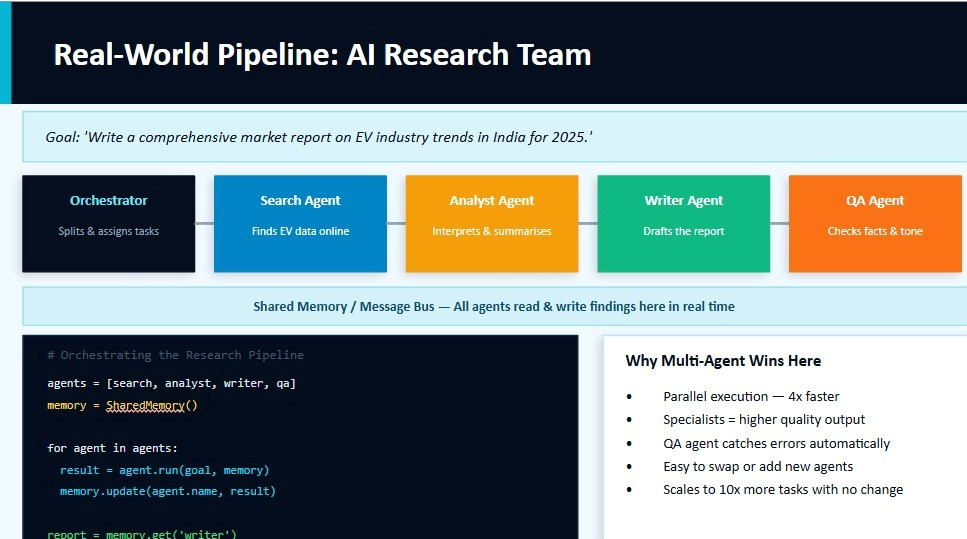

In [6]:
import requests
import os
from dotenv import load_dotenv
load_dotenv()

API_KEY = os.getenv("API_KEY_HUGG")
API_URL = "https://router.huggingface.co/v1/chat/completions"

headers = {
    "Authorization": f"Bearer {API_KEY}",
    "Content-Type": "application/json"
}

MODEL_ID = "meta-llama/Meta-Llama-3-8B-Instruct"


class SharedMemory:
    def __init__(self):
        self.data = {}
    def update(self,key,value):
        self.data[key] = value
    def get(self,key):
        return self.data.get(key,"")


def call_llm(prompt):
    payload={
        "model":MODEL_ID,
        "messages":[{"role":"user","content":prompt}],
        "max_tokens":1000
    }
    response = requests.post(API_URL,headers=headers,json=payload)
    data= response.json()["choices"][0]["message"]["content"]
    return data


# AGENTS
def search_agent(goal,memory):
    print("Search Agent")
    result = call_llm(f"{goal} . Search trends and Key market for EV in india in 2025")
    memory.update("search",result)

def analyst_agent(memory):
    print("Analyst agent")
    data = memory.get("search")
    result = call_llm(f"As an Analyst Analyze this data:{data} keep it short and consice with bullet points") # it will work better with structured prompt
    memory.update("analysis",result)

def writer_agent(memory):
    print("writer agent")
    analysis = memory.get("analysis")
    result = call_llm(f"Write EV marker report for india 2025:{analysis} keep it short and concise")
    memory.update("report",result)

def qa_agent(memory):
    print("QA Agent")
    report = memory.get("report")
    result = call_llm(f"Check the facts and Tone of the {report} keep it short and concise")
    memory.update("final",result)


def run(goal):
    print("Goal",goal)
    memory = SharedMemory()
    search_agent(goal,memory)
    analyst_agent(memory)
    writer_agent(memory)
    qa_agent(memory)
    return memory.get("final")

goal = "Write a comprehensive market report on EV industry trends in INdia for 2025"
output = run(goal)
print(output)

Goal Write a comprehensive market report on EV industry trends in INdia for 2025
Search Agent
Analyst agent
writer agent
QA Agent
**Facts Verification:**

1. **Government Initiatives:** Correct. The Indian government has launched several initiatives to promote electric vehicle adoption, such as the FAME (Faster Adoption and Manufacturing of Electric Vehicles in India) scheme.
2. **Electric Two-Wheelers:** Correct. The market for electric two-wheelers in India is growing rapidly, with a 30% growth rate per annum.
3. **Public Charging Infrastructure:** Correct. The number of public charging points in India is increasing, with a 20% growth rate per annum.
4. **Key Players:** Correct. The companies mentioned (Tata Motors, Hyundai, Mahindra, Ather Energy, and Okinawa Scooters) are prominent players in the Indian electric vehicle market.
5. **Market Forecasts:** Correct. The forecasts for electric two-wheelers, electric four-wheelers, and public charging infrastructure by 2025 are reasonable

In [ ]:
import os
import google.generativeai as genai
from dotenv import load_dotenv

load_dotenv()

API_KEY = os.getenv("API_KEY")
genai.configure(api_key=API_KEY)

model = genai.GenerativeModel('gemini-3-flash-preview')

class SharedMemory:
    def __init__(self):
        self.data = {}
    def update(self, key, value):
        self.data[key] = value
    def get(self, key):
        return self.data.get(key, "")

def call_llm(prompt):
    response = model.generate_content(prompt)
    return response.text

def search_agent(goal, memory):
    print("Search Agent running...")
    result = call_llm(f"{goal} . Search trends and Key market for EV in india in 2025")
    memory.update("search", result)

def analyst_agent(memory):
    print("Analyst Agent running...")
    data = memory.get("search")
    result = call_llm(f"As an Analyst Analyze this data:{data} keep it short and consice with bullet points")
    memory.update("analysis", result)

def writer_agent(memory):
    print("Writer Agent running...")
    analysis = memory.get("analysis")
    result = call_llm(f"Write EV marker report for india 2025:{analysis} keep it short and concise")
    memory.update("report", result)

def qa_agent(memory):
    print("QA Agent running...")
    report = memory.get("report")
    result = call_llm(f"Check the facts and Tone of the {report} keep it short and concise")
    memory.update("final", result)

def run(goal):
    print("Goal:", goal)
    memory = SharedMemory()
    search_agent(goal, memory)
    analyst_agent(memory)
    writer_agent(memory)
    qa_agent(memory)
    return memory.get("final")

goal = "Write a comprehensive market report on EV industry trends in INdia for 2025"
output = run(goal)

print("\n--- FINAL OUTPUT ---\n")
print(output)

Goal: Write a comprehensive market report on EV industry trends in INdia for 2025
Search Agent running...
Analyst Agent running...
